# Layer 3 (PFF): RQ3 part 2, the LSTM spatial memory model

The proposal's RQ3 model: an LSTM reads a teammate's k most recent known positions and predicts where they are at the moment of the pass. It is compared with naive linear extrapolation.

Here the known positions are the **seen history** built in `11_layer3_pff_rq3_memory.ipynb`: the moments in the 5 s before the pass when the teammate was inside the passer's vision cone (at most the 20 most recent, 10 per second). The target is where PFF tracked the teammate at the moment of the pass. Only teammates tracked on camera (VISIBLE) at that moment are used as targets, so the model is never trained or scored against PFF's own off-screen estimates.

**Methods compared**, all with exactly the same information:

- **Last seen:** the teammate is where the passer last saw them.
- **Linear extrapolation (constant velocity):** the movement over the last 0.3 s of viewing is continued until the pass. This is the proposal's naive baseline.
- **LSTM:** two stacked LSTM layers (hidden size 64) and a small output layer, the same architecture as in the StatsBomb version. It reads the seen history and is reported in two forms:
  - **direct:** it predicts how far the teammate has moved since last seen, as in the StatsBomb version;
  - **correcting the extrapolation (main):** it starts from the linear extrapolation and learns a correction, for example that players slow down or curve their runs. The extrapolated movement is given to it as an extra input. This is a standard way to let a network build on a strong simple baseline instead of relearning it.

**Out-of-sample predictions for every game.** The proposal planned a held-out competition, but PFF covers one competition. So the 64 games are split into 5 folds. For each fold, an LSTM is trained on the other four and predicts the held-out fold (cross-fitting). Every prediction comes from a model that never saw that game.

In [1]:
# shared figure settings used in every notebook:
# colours (navy, green, grey and light blue) and one folder for every saved figure
import matplotlib.pyplot as plt
from cycler import cycler
from pathlib import Path
plt.rcParams['axes.prop_cycle'] = cycler(color=['#1E2761', '#2C5F2D', '#9AA0A6', '#7F8FC0'])

FIGURES = Path('../data/results/figures')
FIGURES.mkdir(parents=True, exist_ok=True)


def save_fig(fig, name):
    """Save a figure to the shared figures folder, in the same format in every notebook."""
    fig.savefig(FIGURES / name, dpi=200, bbox_inches='tight', facecolor='white')
    print(f"saved {FIGURES / name}")


import sys, os, json, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.nn.utils.rnn import pack_padded_sequence

RESULTS = Path('../data/results')
MODEL_DIR = RESULTS / 'pff_lstm'
MODEL_DIR.mkdir(parents=True, exist_ok=True)

mates = pd.read_pickle(RESULTS / 'pff_memory_mates.pkl')
hist_all = np.load(RESULTS / 'pff_memory_hist.npy', mmap_mode='r')
TAU = json.load(open(RESULTS / 'pff_tau.json'))['tau_m']

# examples: teammates outside the cone at the pass whom the passer saw in the previous 5 s
rows = np.flatnonzero((~mates['in_cone'].to_numpy()) & (mates['n_seen'].fillna(0).to_numpy() > 0))
ex = mates.iloc[rows].reset_index().rename(columns={'index': 'mate_row'})
H = np.asarray(hist_all[rows], dtype=np.float32)
ex['visible_target'] = ex['target_visible'].to_numpy()
print(f"{len(ex)} unseen teammates with a seen history, {ex['visible_target'].sum()} tracked on camera at the pass")
print(f"tau = {TAU:.2f} m; torch {torch.__version__}")

227460 unseen teammates with a seen history, 132511 tracked on camera at the pass
tau = 4.66 m; torch 2.14.0+cpu


## 1. Folds and the two baselines

Games are assigned at random to 5 folds of 12 to 13 games each.

**Constant velocity** uses the seen sample closest to 0.3 s before the last sighting:

- its velocity is capped at 10 m/s;
- if there is no such sample, it falls back to last seen.

The window was chosen as the best of 0.1, 0.3, 0.5 and 1 s on these data, which gives the baseline its best case.

In [2]:
N_FOLDS = 5
games = sorted(ex['pff_game_id'].unique())
rng = np.random.default_rng(42)
shuffled = [int(g) for g in rng.permutation(games)]
folds = [shuffled[i::N_FOLDS] for i in range(N_FOLDS)]
fold_of = {g: f for f, gs in enumerate(folds) for g in gs}
ex['fold'] = ex['pff_game_id'].map(fold_of)
json.dump(folds, open(MODEL_DIR / 'folds.json', 'w'))
print('games per fold:', [len(f) for f in folds])

last = H[:, -1, :]
gap = last[:, 2]                       # seconds between last sighting and the pass
ex['pred_last_x'], ex['pred_last_y'] = last[:, 0], last[:, 1]


def constant_velocity(H, back=0.3, max_speed=10.0):
    last = H[:, -1, :]
    tt = H[:, :, 2]
    d = np.abs(tt - (last[:, 2:3] + back))
    d[np.isnan(d)] = np.inf
    k = d.argmin(1)
    p = H[np.arange(len(H)), k]
    dt = p[:, 2] - last[:, 2]
    ok = (dt >= 0.05) & ~np.isnan(p[:, 0])
    v = np.zeros((len(H), 2), dtype=np.float32)
    v[ok] = (last[ok, :2] - p[ok, :2]) / dt[ok, None]
    sp = np.hypot(v[:, 0], v[:, 1])
    v *= np.minimum(1.0, max_speed / np.maximum(sp, 1e-9))[:, None]
    return last[:, :2] + v * last[:, 2:3], ok


cv, cv_ok = constant_velocity(H)
ex['pred_cv_x'], ex['pred_cv_y'] = cv[:, 0], cv[:, 1]
ex['cv_has_velocity'] = cv_ok
print(f"constant velocity has a velocity for {cv_ok.mean():.1%} of examples")

games per fold: [13, 13, 13, 13, 12]
constant velocity has a velocity for 95.1% of examples


## 2. The LSTM

Each step of the seen history is described by five numbers:

1. and 2. the position relative to where the teammate was last seen (x and y, divided by 10 m);
3. and 4. the position on the pitch (x divided by 52.5 m, y divided by 34 m);
5. the time from that moment to the pass (divided by 5 s).

The **direct** model predicts the movement from the last sighting to the pass.

The **main** model gets two extra numbers at every step: the movement the linear extrapolation predicts (x and y, divided by 10 m). It predicts the difference between the extrapolation and the true position.

For both, the loss is the average Euclidean error, and training uses only VISIBLE targets from the four training folds, for 12 passes over the data.

Each fold's model is saved, so a finished fold is not retrained if the cell is rerun.

In [3]:
POS_SCALE, TIME_SCALE = 10.0, 5.0
K_MAX = H.shape[1]


def build_features(H, k, extra=None):
    h = H[:, -k:, :]
    n = (~np.isnan(h[:, :, 0])).sum(1)
    last = h[:, -1, :]
    f = np.zeros((len(h), k, 5), dtype=np.float32)
    f[..., 0] = (h[..., 0] - last[:, None, 0]) / POS_SCALE
    f[..., 1] = (h[..., 1] - last[:, None, 1]) / POS_SCALE
    f[..., 2] = h[..., 0] / 52.5
    f[..., 3] = h[..., 1] / 34.0
    f[..., 4] = h[..., 2] / TIME_SCALE
    f = np.nan_to_num(f, nan=0.0)
    if extra is not None:                                     # the same extra numbers at every real step
        e = np.repeat(extra[:, None, :], k, axis=1) * (~np.isnan(h[:, :, :1]))
        f = np.concatenate([f, e.astype(np.float32)], axis=2)
    idx = (np.arange(k)[None, :] + (k - n)[:, None]) % k      # move padding to the end for packing
    f = np.take_along_axis(f, idx[:, :, None], axis=1)
    return f, n, last


class TrajectoryLSTM(nn.Module):
    def __init__(self, n_features=5, hidden=64, layers=2, dropout=0.1):
        super().__init__()
        self.lstm = nn.LSTM(n_features, hidden, num_layers=layers, batch_first=True, dropout=dropout)
        self.head = nn.Sequential(nn.Linear(hidden, 64), nn.ReLU(), nn.Linear(64, 2))

    def forward(self, x, lengths):
        packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
        _, (h, _) = self.lstm(packed)
        return self.head(h[-1])


def predict(model, X, L, batch_size=8192):
    model.eval()
    out = []
    with torch.no_grad():
        for s in range(0, len(X), batch_size):
            out.append(model(torch.from_numpy(X[s:s + batch_size]),
                             torch.from_numpy(L[s:s + batch_size].astype(np.int64))).numpy())
    return np.concatenate(out) * POS_SCALE


def train(X, L, Y, epochs=12, batch_size=1024, seed=0):
    torch.manual_seed(seed)
    model = TrajectoryLSTM(n_features=X.shape[2])
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    Xt, Lt, Yt = torch.from_numpy(X), torch.from_numpy(L.astype(np.int64)), torch.from_numpy(Y)
    for epoch in range(epochs):
        model.train()
        order = torch.randperm(len(Xt))
        total = 0.0
        for s in range(0, len(order), batch_size):
            i = order[s:s + batch_size]
            opt.zero_grad()
            loss = torch.linalg.norm(model(Xt[i], Lt[i]) - Yt[i], dim=1).mean()
            loss.backward()
            opt.step()
            total += loss.item() * len(i)
    print(f"    final training error {total / len(Xt) * POS_SCALE:.3f} m")
    return model


def crossfit(k, tag, residual=True, folds_to_run=range(N_FOLDS)):
    last_xy = H[:, -1, :2]
    if residual:
        X, L, _ = build_features(H, k, extra=(cv - last_xy) / POS_SCALE)
        base = cv
    else:
        X, L, _ = build_features(H, k)
        base = last_xy
    target = ex[['x', 'y']].to_numpy(np.float32)
    Y = ((target - base) / POS_SCALE).astype(np.float32)
    pred = np.full((len(ex), 2), np.nan, dtype=np.float32)
    for f in folds_to_run:
        path = MODEL_DIR / f'lstm_{tag}_fold{f}.pt'
        tr = (ex['fold'].to_numpy() != f) & ex['visible_target'].to_numpy()
        te = ex['fold'].to_numpy() == f
        model = TrajectoryLSTM(n_features=X.shape[2])
        if path.exists():
            model.load_state_dict(torch.load(path, map_location='cpu'))
        else:
            t0 = time.time()
            print(f"  fold {f}: training on {tr.sum()} examples")
            model = train(X[tr], L[tr], Y[tr], seed=f)
            torch.save(model.state_dict(), path)
            print(f"  fold {f}: {time.time() - t0:.0f}s")
        pred[te] = base[te] + predict(model, X[te], L[te])
    return pred


print('LSTM, direct:')
p = crossfit(K_MAX, f'direct_k{K_MAX}', residual=False)
ex['pred_lstmd_x'], ex['pred_lstmd_y'] = p[:, 0], p[:, 1]
print('LSTM, correcting the extrapolation (main):')
p = crossfit(K_MAX, f'main_k{K_MAX}', residual=True)
ex['pred_lstm_x'], ex['pred_lstm_y'] = p[:, 0], p[:, 1]
print('cross-fitted predictions for all', len(ex), 'examples')

LSTM, direct:
  fold 0: training on 106406 examples
    final training error 3.062 m
  fold 0: 281s
  fold 1: training on 105205 examples
    final training error 3.076 m
  fold 1: 278s
  fold 2: training on 105257 examples
    final training error 3.086 m
  fold 2: 281s
  fold 3: training on 105593 examples
    final training error 3.066 m
  fold 3: 281s
  fold 4: training on 107583 examples
    final training error 3.076 m
  fold 4: 290s
LSTM, correcting the extrapolation (main):
  fold 0: training on 106406 examples
    final training error 3.006 m
  fold 0: 272s
  fold 1: training on 105205 examples
    final training error 3.027 m
  fold 1: 271s
  fold 2: training on 105257 examples
    final training error 3.045 m
  fold 2: 278s
  fold 3: training on 105593 examples
    final training error 3.019 m
  fold 3: 283s
  fold 4: training on 107583 examples
    final training error 3.024 m
  fold 4: 1588s
cross-fitted predictions for all 227460 examples


## 3. Accuracy: LSTM against the baselines

Mean, median and 90th percentile error in metres on teammates tracked on camera at the pass. The match bootstrap resamples whole games 5000 times. The last column is the share of teammates predicted within tau: the memory-feasible share for each method.

In [4]:
for name in ['last', 'cv', 'lstmd', 'lstm']:
    ex[f'err_{name}'] = np.hypot(ex[f'pred_{name}_x'] - ex['x'], ex[f'pred_{name}_y'] - ex['y'])
ev = ex[ex['visible_target']].copy()
labels = {'last': 'last seen', 'cv': 'linear extrapolation', 'lstmd': 'LSTM, direct', 'lstm': 'LSTM, main'}
table = pd.DataFrame({labels[n]: {'mean (m)': ev[f'err_{n}'].mean(), 'median (m)': ev[f'err_{n}'].median(),
                                  '90th pct (m)': ev[f'err_{n}'].quantile(0.9),
                                  f'within tau ({TAU:.2f} m)': (ev[f'err_{n}'] < TAU).mean()}
                      for n in ['last', 'cv', 'lstmd', 'lstm']}).T
print(f"{len(ev)} teammates")
print(table.round(3))


def game_bootstrap(df, worse, better, n_boot=5000, seed=0):
    g = df.groupby('pff_game_id').agg(w=(worse, 'sum'), b=(better, 'sum'), n=(worse, 'size'))
    r = np.random.default_rng(seed)
    idx = r.integers(0, len(g), size=(n_boot, len(g)))
    gain = (g['w'].to_numpy()[idx].sum(1) - g['b'].to_numpy()[idx].sum(1)) / g['n'].to_numpy()[idx].sum(1)
    point = (g['w'].sum() - g['b'].sum()) / g['n'].sum()
    return pd.Series({'gain (m)': point, 'ci low': np.percentile(gain, 2.5), 'ci high': np.percentile(gain, 97.5),
                      'games won': f"{((g['w'] - g['b']) > 0).sum()}/{len(g)}"})


print()
print(pd.DataFrame({'LSTM (main) vs last seen': game_bootstrap(ev, 'err_last', 'err_lstm'),
                    'LSTM (main) vs linear extrapolation': game_bootstrap(ev, 'err_cv', 'err_lstm'),
                    'LSTM (main) vs LSTM (direct)': game_bootstrap(ev, 'err_lstmd', 'err_lstm'),
                    'linear extrapolation vs last seen': game_bootstrap(ev, 'err_last', 'err_cv')}).T)

132511 teammates
                      mean (m)  median (m)  90th pct (m)  within tau (4.66 m)
last seen                4.057       2.693         9.457                0.693
linear extrapolation     3.794       1.935         9.758                0.728
LSTM, direct             3.060       1.723         7.641                0.784
LSTM, main               3.026       1.681         7.622                0.784

                                     gain (m)    ci low   ci high games won
LSTM (main) vs last seen             1.031639  1.012049  1.052086     64/64
LSTM (main) vs linear extrapolation  0.768097   0.74351  0.794914     64/64
LSTM (main) vs LSTM (direct)         0.034338  0.027377  0.041624     57/64
linear extrapolation vs last seen    0.263542  0.229367  0.297367     60/64


**What this shows**

**The LSTM locates unseen teammates far better than either baseline.** On 132511 unseen teammates tracked on camera at the pass:

| Method | Mean error | Median error | Within tau (4.66 m) |
|---|---|---|---|
| Last seen | 4.06 m | 2.69 m | 69.3% |
| Linear extrapolation | 3.79 m | 1.94 m | 72.8% |
| LSTM, direct | 3.06 m | 1.72 m | 78.4% |
| LSTM, main | 3.03 m | 1.68 m | 78.4% |

**The gains are large and consistent.** Resampling whole games, the main LSTM beats:

- last seen by 1.03 m (95 percent CI 1.01 to 1.05), better in all 64 games;
- linear extrapolation by 0.77 m (0.74 to 0.79), also in all 64 games.

Linear extrapolation itself beats last seen by 0.26 m. With continuous tracking, a teammate's recent movement is informative, unlike in the StatsBomb freeze frames.

**Both LSTM versions do almost equally well.** The main version (correcting the extrapolation) is better by only 0.03 m (CI 0.03 to 0.04, 57 of 64 games). So the result does not depend on that design choice. The direct version, which has the same structure as the StatsBomb LSTM, gets nearly all of the benefit.

**Compared with the StatsBomb version.** There, the LSTM beat last position by only 0.10 m. With PFF it gains 1 m, because the history is what the passer actually saw, continuous and correctly identified, rather than sparse freeze frames linked into anonymous tracks.

## 4. How error grows with time since the teammate was last seen

          teammates  last_seen  linear  lstm_direct   lstm  lstm_within_tau
gap_band                                                                   
0-0.5 s       18848      0.636   0.293        0.387  0.297            0.998
0.5-1 s       21528      1.615   0.865        0.861  0.811            0.990
1-2 s         31628      3.097   2.259        1.975  1.958            0.935
2-3 s         24158      4.992   4.543        3.703  3.692            0.734
3-5 s         36349      7.493   8.181        6.265  6.240            0.453


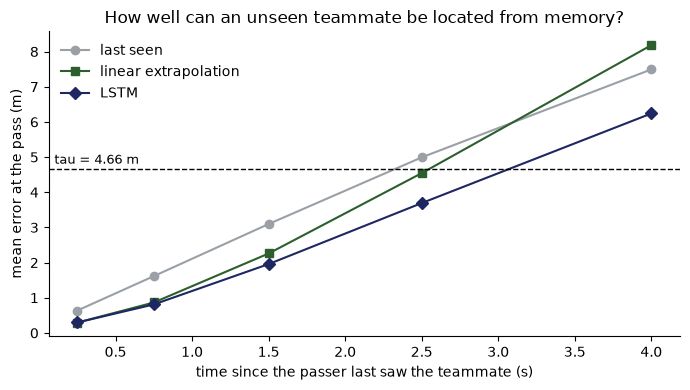

In [5]:
ev['gap_band'] = pd.cut(ev['gap_s'], [0, 0.5, 1, 2, 3, 5], labels=['0-0.5 s', '0.5-1 s', '1-2 s', '2-3 s', '3-5 s'],
                        include_lowest=True)
by_gap = ev.groupby('gap_band', observed=True).agg(
    teammates=('err_lstm', 'size'),
    last_seen=('err_last', 'mean'), linear=('err_cv', 'mean'), lstm_direct=('err_lstmd', 'mean'),
    lstm=('err_lstm', 'mean'),
    lstm_within_tau=('err_lstm', lambda e: (e < TAU).mean()))
print(by_gap.round(3))

NAVY, GREEN, GREY = '#1E2761', '#2C5F2D', '#9AA0A6'
mid = [0.25, 0.75, 1.5, 2.5, 4.0]
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(mid, by_gap['last_seen'], 'o-', color=GREY, label='last seen')
ax.plot(mid, by_gap['linear'], 's-', color=GREEN, label='linear extrapolation')
ax.plot(mid, by_gap['lstm'], 'D-', color=NAVY, label='LSTM')
ax.axhline(TAU, color='black', ls='--', lw=1)
ax.text(0.1, TAU + 0.15, f'tau = {TAU:.2f} m', fontsize=9)
ax.set_xlabel('time since the passer last saw the teammate (s)')
ax.set_ylabel('mean error at the pass (m)')
ax.spines[['top', 'right']].set_visible(False)
ax.legend(frameon=False)
ax.set_title('How well can an unseen teammate be located from memory?')
plt.tight_layout()
save_fig(plt.gcf(), 'rq3_pff_lstm_by_gap.png')
plt.show()

**What this shows**

**The LSTM's advantage grows with time since the teammate was last seen:**

| Time since last seen | Last seen | Linear extrapolation | LSTM |
|---|---|---|---|
| Under 0.5 s ago | 0.64 m | 0.29 m | 0.30 m |
| 0.5 to 1 s | 1.62 m | 0.87 m | 0.81 m |
| 1 to 2 s | 3.10 m | 2.26 m | 1.96 m |
| 2 to 3 s | 4.99 m | 4.54 m | 3.69 m |
| 3 to 5 s | 7.49 m | 8.18 m | 6.24 m |

For a teammate seen less than half a second ago, extrapolating their movement is already almost perfect, and the LSTM matches it. The longer a teammate is out of view, the more they turn, slow down or change runs. A straight-line guess then overshoots, and is even worse than "they have not moved" after 3 s. The LSTM has learned how players typically move and does best at every gap.

**Memory stays within tau for about 2 s, then fades.** The share of teammates the LSTM places within 4.66 m:

| Time since last seen | Within tau |
|---|---|
| Up to 1 s ago | about 99% |
| 1 to 2 s | 93.5% |
| 2 to 3 s | 73.4% |
| 3 to 5 s | 45.3% |

In football terms: a teammate seen in the last couple of seconds can be reliably "remembered", one seen longer ago often cannot.

## 5. Sensitivity to the history length k

The proposal specified history windows of 5, 10 and 15. Here the longest history is 20 seen samples. This retrains the main LSTM on fold 0 only, with at most 5, 10 and 20 samples, and compares the error on fold 0's teammates.

In [6]:
f0 = (ex['fold'] == 0) & ex['visible_target']
res = {}
for k in [5, 10, 20]:
    pk = crossfit(k, f'main_k{k}', residual=True, folds_to_run=[0])
    e = np.hypot(pk[f0.to_numpy(), 0] - ex.loc[f0, 'x'], pk[f0.to_numpy(), 1] - ex.loc[f0, 'y'])
    res[f'k = {k}'] = {'mean (m)': e.mean(), 'median (m)': np.median(e), f'within tau': (e < TAU).mean()}
print(pd.DataFrame(res).T.round(3))

  fold 0: training on 106406 examples
    final training error 3.049 m
  fold 0: 53s
  fold 0: training on 106406 examples
    final training error 3.027 m
  fold 0: 122s
        mean (m)  median (m)  within tau
k = 5      3.138       1.791       0.774
k = 10     3.120       1.766       0.776
k = 20     3.096       1.753       0.778


**What this shows:** the history length makes little difference: 3.14 m with up to 5 seen samples, 3.12 m with 10 and 3.10 m with 20 (fold 0). More history helps slightly, but most of the information is in the last half-second or so of viewing. This matches the StatsBomb version, where k = 5, 10 and 15 also gave almost identical errors. The proposal's choice of k is therefore not critical, and k = 20 (up to 2 s of viewing) is used.

## 6. Save

In [7]:
cols = ['mate_row', 'pff_game_id', 'possession_event_id', 'mate_id', 'fold', 'visible_target', 'gap_s', 'n_seen',
        'pred_last_x', 'pred_last_y', 'pred_cv_x', 'pred_cv_y', 'pred_lstmd_x', 'pred_lstmd_y',
        'pred_lstm_x', 'pred_lstm_y', 'err_last', 'err_cv', 'err_lstmd', 'err_lstm']
ex[cols].to_pickle(RESULTS / 'pff_lstm_predictions.pkl')
print('saved pff_lstm_predictions.pkl:', len(ex), 'rows')

saved pff_lstm_predictions.pkl: 227460 rows


## Summary

**The LSTM spatial memory model works on what the passer actually saw.** The history is the moments a teammate was inside the passer's vision cone in the previous 5 s. From that, the cross-fitted LSTM places unseen teammates with a mean error of 3.03 m (median 1.68 m) on 132511 teammates tracked on camera.

**It clearly beats both baselines, in every one of the 64 games:**

- by 1.03 m against last seen (95 percent CI 1.01 to 1.05);
- by 0.77 m against the proposal's linear extrapolation (0.74 to 0.79).

**It places 78.4 percent of unseen teammates within tau (4.66 m).** That is against 72.8 percent for linear extrapolation and 69.3 percent for last seen. H3 predicted a mean error below the 3 to 5 m threshold, and 3.03 m meets it.

**Memory is short.** Accuracy stays within tau for about 99 percent of teammates seen in the last second and 93.5 percent of those seen 1 to 2 s ago, then falls to 45.3 percent after 3 to 5 s.

**The result is robust.**

- Two LSTM versions differ by only 0.03 m.
- The history length (k = 5, 10, 20) changes the error by less than 0.05 m.

**Next:** `13_layer3_pff_rq3_answer.ipynb` uses these predictions to answer RQ3. How many blind passes went to a teammate the passer could have remembered to within tau, do blind passes favour such teammates, and would the pass have arrived?